<a href="https://colab.research.google.com/github/introvet7/ksvd/blob/main/%D0%9B%D0%A0_6_%D0%9A%D0%A1%D0%92%D0%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Кияшко Ілля ФІТ 3-8
ФІТ 3-8, КСВД ЛР-6



In [ ]:
import altair as alt
from vega_datasets import data
import pandas as pd

## Завдання 1
Гістограма кількості днів кожного типу погоди в Сіетлі.

Вимоги:
* Верхні краї стовпців — заокруглені.
* Порядок по частоті (від найчастішої до найрідшої погоди).
* Колір — залежить від типу погоди.

In [ ]:
source_weather = data.seattle_weather()

chart1 = alt.Chart(source_weather).mark_bar(cornerRadiusTopLeft=10, cornerRadiusTopRight=10).encode(
    x=alt.X('weather:N', sort='-y', title='Тип погоди'),
    y=alt.Y('count():Q', title='Кількість днів'),
    color=alt.Color('weather:N', legend=None)
).properties(
    title='Кількість днів кожного типу погоди в Сіетлі',
    width=400
)

chart1

alt.Chart(...)

## Завдання 2
Горизонтальна стовпчикова діаграма врожайності сорту ячменю по місцях у 1931 році.

Вимоги:
* По осі Y — сорти.
* Колір — місце вирощування.
* Дані — лише за 1931 рік.
* Сортування по врожайності.

In [ ]:
source_barley = data.barley()
barley_1931 = source_barley[source_barley['year'] == 1931]

chart2 = alt.Chart(barley_1931).mark_bar().encode(
    x=alt.X('sum(yield):Q', title='Врожайність'),
    y=alt.Y('variety:N', sort='-x', title='Сорт ячменю'),
    color=alt.Color('site:N', title='Місце вирощування')
).properties(
    title='Врожайність сортів ячменю по місцях (1931 рік)',
    width=500
)

chart2

alt.Chart(...)

## Завдання 3
Гістограма кількості днів певного типу погоди по місяцях.

Вимоги:
* По осі X — місяці.
* По осі Y — кількість.
* Колір — тип погоди.
* Групування: по типу погоди в кожному місяці (груповані стовпчики).

In [ ]:
chart3 = alt.Chart(source_weather).mark_bar().encode(
    x=alt.X('month(date):O', title='Місяць'),
    y=alt.Y('count():Q', title='Кількість днів'),
    color=alt.Color('weather:N', title='Тип погоди'),
    xOffset='weather:N'
).properties(
    title='Кількість днів певного типу погоди по місяцях',
    width=600
)

chart3

alt.Chart(...)

## Завдання 4
Лінійно-обласна діаграма цін акцій.

Вимоги:
* Відобразіть лише компанії "GOOG" та "AAPL".
* Колір градієнтний залежно від ціни.
* Поверх градієнта — лінія.

In [ ]:
source_stocks = data.stocks()
stocks_filtered = source_stocks[source_stocks['symbol'].isin(['GOOG', 'AAPL'])]

chart4 = alt.Chart(stocks_filtered).mark_area(line={'color': 'darkblue'}).encode(
    x=alt.X('date:T', title='Дата'),
    y=alt.Y('price:Q', title='Ціна'),
    color=alt.Color('price:Q', scale=alt.Scale(scheme='blues'), title='Ціна (градієнт)'),
    facet=alt.Facet('symbol:N', columns=2, title='Компанія')
).properties(
    title='Динаміка цін акцій GOOG та AAPL',
    width=350,
    height=250
)

chart4

alt.Chart(...)

## Завдання 5
Потоковий граф (stack='center') рівня безробіття в різних галузях.

Вимоги:
* Використовуйте data.unemployment_across_industries.url.
* По осі X — дата.
* По осі Y — кількість безробітних.
* Колір — назва галузі.
* Додайте можливість взаємодії (інтерактивність).

In [ ]:
url = data.unemployment_across_industries.url

chart5 = alt.Chart(url).mark_area().encode(
    x=alt.X('yearmonth(date):T', title='Дата'),
    y=alt.Y('sum(count):Q', stack='center', title='Кількість безробітних', axis=None),
    color=alt.Color('series:N', title='Галузь')
).interactive().properties(
    title='Рівень безробіття в різних галузях',
    width=700,
    height=300
)

chart5

alt.Chart(...)

## Завдання 6
На основі `data.seattle_weather()` побудуйте кільцеву діаграму.

Вимоги:
* Частки кожного типу погоди у вигляді кільцевої діаграми.
* Покажіть у центрі кільця середнє значення температури.
* Використовуйте mark_arc з innerRadius.

In [ ]:
avg_temp_val = source_weather['temp_max'].mean()

donut = alt.Chart(source_weather).mark_arc(innerRadius=70).encode(
    theta=alt.Theta('count():Q', title='Кількість'),
    color=alt.Color('weather:N', title='Тип погоди')
)

text = alt.Chart(pd.DataFrame({'text': [f"{avg_temp_val:.1f}°C"]})).mark_text(
    size=24,
    fontWeight='bold'
).encode(
    text='text:N'
)

chart6 = (donut + text).properties(
    title='Частки типів погоди та середня макс. температура',
    width=300,
    height=300
)

chart6

alt.LayerChart(...)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

### Фрактал 1: Папороть Барнслі (Barnsley Fern)


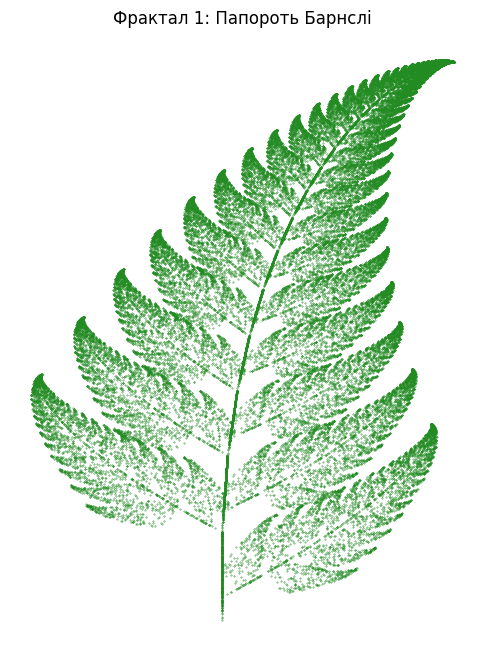

In [ ]:
def draw_barnsley_fern(iters=50000):
    # Початкові координати
    x, y = 0, 0
    x_list, y_list = [], []

    for _ in range(iters):
        r = np.random.random()
        # Ймовірності застосування різних трансформацій
        if r < 0.01:
            nx, ny = 0, 0.16 * y
        elif r < 0.86:
            nx, ny = 0.85 * x + 0.04 * y, -0.04 * x + 0.85 * y + 1.6
        elif r < 0.93:
            nx, ny = 0.2 * x - 0.26 * y, 0.23 * x + 0.22 * y + 1.6
        else:
            nx, ny = -0.15 * x + 0.28 * y, 0.26 * x + 0.24 * y + 0.44

        x, y = nx, ny
        x_list.append(x)
        y_list.append(y)

    plt.figure(figsize=(6, 8))
    plt.scatter(x_list, y_list, s=0.1, color='forestgreen')
    plt.title("Фрактал 1: Папороть Барнслі")
    plt.axis('off')
    plt.show()

draw_barnsley_fern()

### Фрактал 2: Множина Жуліа (Julia Set)


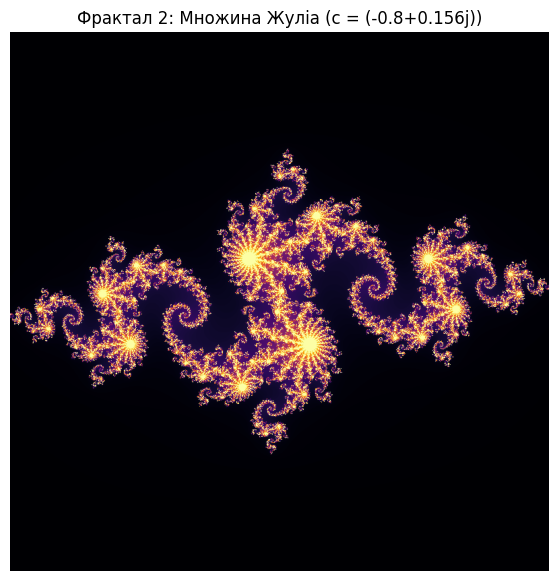

In [ ]:
def draw_julia_set(c=-0.8 + 0.156j, width=800, height=800, max_iter=256):
    # Створення сітки координат на комплексній площині
    x, y = np.meshgrid(np.linspace(-1.5, 1.5, width), np.linspace(-1.5, 1.5, height))
    z = x + 1j * y
    img = np.zeros(z.shape, dtype=int)

    # Відстеження точок, які не "втекли" в нескінченність
    mask = np.ones(z.shape, dtype=bool)

    for i in range(max_iter):
        z[mask] = z[mask]**2 + c
        mask = np.abs(z) < 2
        img += mask

    plt.figure(figsize=(7, 7))
    plt.imshow(img, cmap='inferno', extent=[-1.5, 1.5, -1.5, 1.5])
    plt.title(f"Фрактал 2: Множина Жуліа (c = {c})")
    plt.axis('off')
    plt.show()

draw_julia_set()

### Фрактал 3: Килим Серпінського (Sierpinski Carpet)


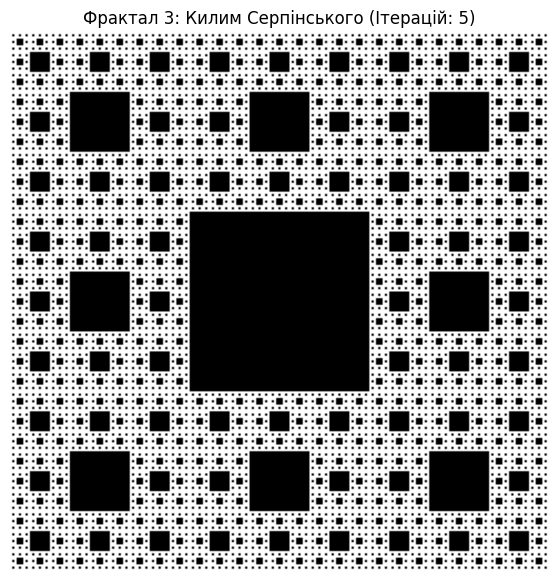

In [ ]:
def draw_sierpinski_carpet(n=5):
    # Розмір матриці (3 в степені n)
    size = 3**n
    # Створюємо суцільний квадрат (заповнений одиницями)
    carpet = np.ones((size, size))

    for i in range(1, n + 1):
        step = 3**(n - i)
        # Вирізаємо центральні квадрати на кожній ітерації
        for x in range(step, size, 3 * step):
            for y in range(step, size, 3 * step):
                carpet[x:x+step, y:y+step] = 0

    plt.figure(figsize=(7, 7))
    plt.imshow(carpet, cmap='bone')
    plt.title(f"Фрактал 3: Килим Серпінського (Ітерацій: {n})")
    plt.axis('off')
    plt.show()

draw_sierpinski_carpet(n=5)